## Import & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/hr_cleaned.csv')
print("Data loaded!")
print("Shape:", df.shape)

Data loaded!
Shape: (1470, 36)


##  Attrition Distribution

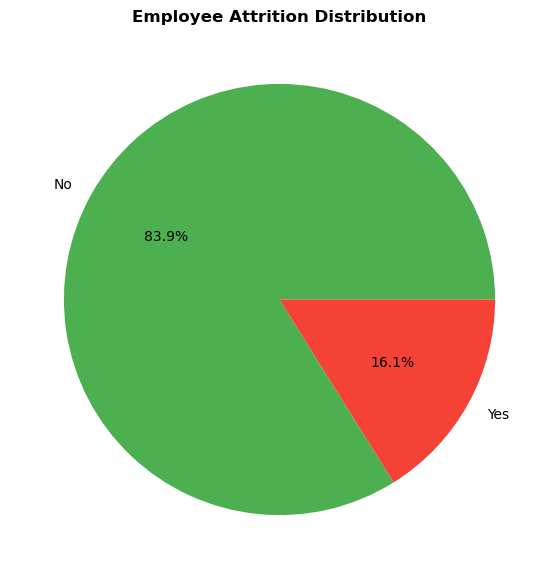

Chart saved!


In [3]:
# Count attrition Yes and No
attrition_count = df['Attrition'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(attrition_count,
        labels=attrition_count.index,
        autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'])
plt.title('Employee Attrition Distribution', fontweight='bold')
plt.savefig('../outputs/02_attrition_distribution.png')
plt.show()
print("Chart saved!")

## Attrition by Department

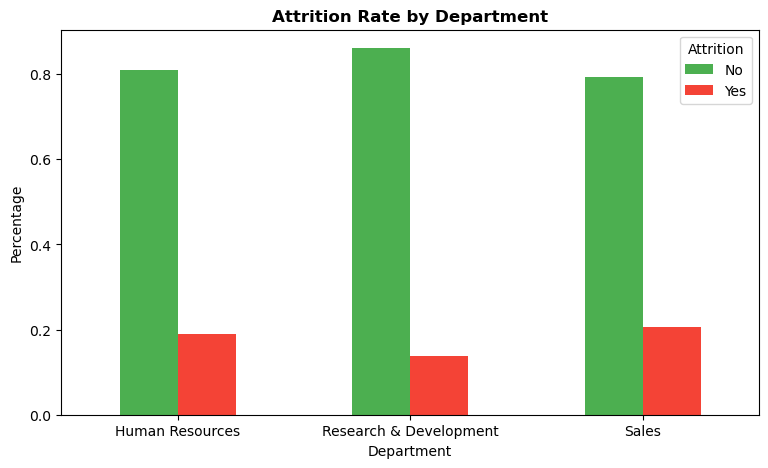

Chart saved!


In [4]:
# Which department loses most employees
dept_attr = df.groupby('Department')['Attrition']\
              .value_counts(normalize=True)\
              .unstack()

dept_attr.plot(kind='bar', figsize=(9, 5),
               color=['#4CAF50', '#F44336'])
plt.title('Attrition Rate by Department', fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.savefig('../outputs/02_attrition_by_dept.png')
plt.show()
print("Chart saved!")

## Attrition by Job Role

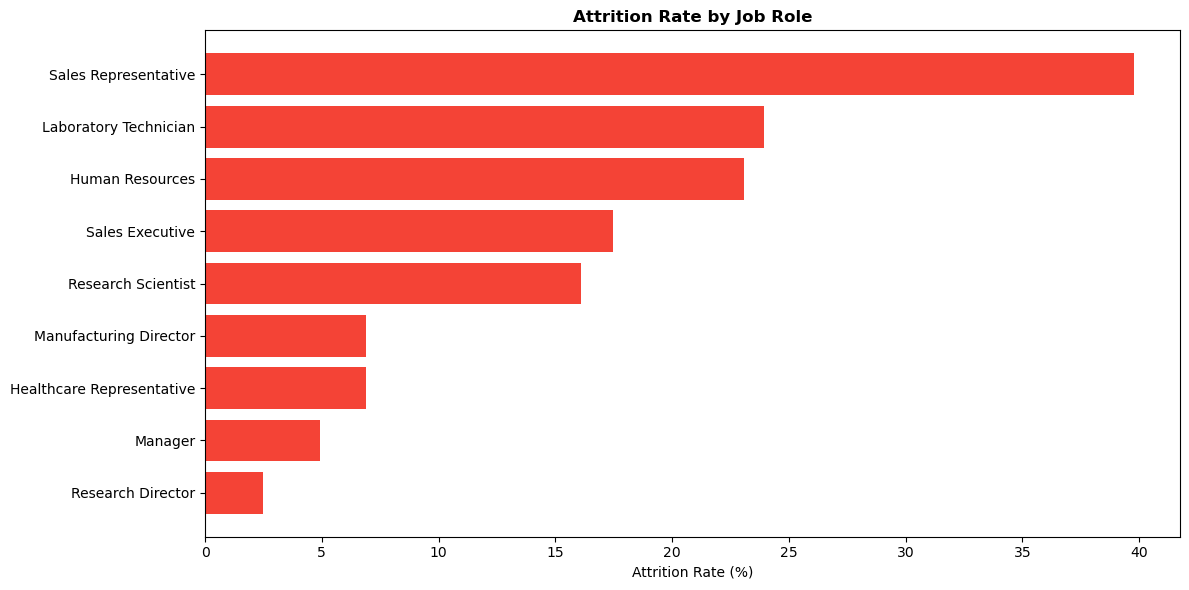

Chart saved!


In [6]:
# Count how many left from each job role
role_yes = df[df['Attrition'] == 'Yes']['JobRole'].value_counts()
role_all = df['JobRole'].value_counts()

# Calculate attrition % for each role
role_pct = round(role_yes / role_all * 100, 2).sort_values(ascending=False)

# Plot chart
plt.figure(figsize=(12, 6))
plt.barh(role_pct.index, role_pct.values, color='#F44336')
plt.title('Attrition Rate by Job Role', fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.savefig('../outputs/02_attrition_by_role.png')
plt.show()
print("Chart saved!")

## Attrition by Overtime

<Figure size 800x500 with 0 Axes>

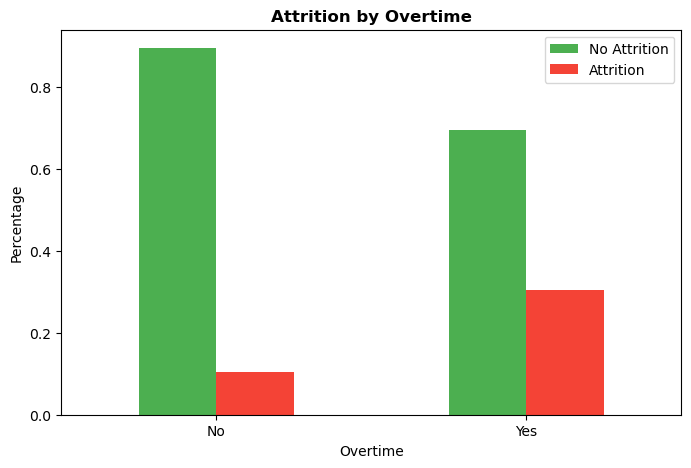

Chart saved!


In [7]:
# We want to check if employees who work overtime
# leave the company more than those who dont

# Group by OverTime column
# normalize=True converts count to percentage
# unstack() makes Yes/No into separate columns
overtime_attr = df.groupby('OverTime')['Attrition']\
                  .value_counts(normalize=True)\
                  .unstack()

plt.figure(figsize=(8, 5))
overtime_attr.plot(kind='bar',
                   color=['#4CAF50', '#F44336'],
                   figsize=(8, 5))
plt.title('Attrition by Overtime', fontweight='bold')
plt.xlabel('Overtime')
plt.ylabel('Percentage')
plt.xticks(rotation=0)  # keeps labels straight not tilted
plt.legend(['No Attrition', 'Attrition'])
plt.savefig('../outputs/02_attrition_by_overtime.png')
plt.show()
print("Chart saved!")

## Salary vs Attrition

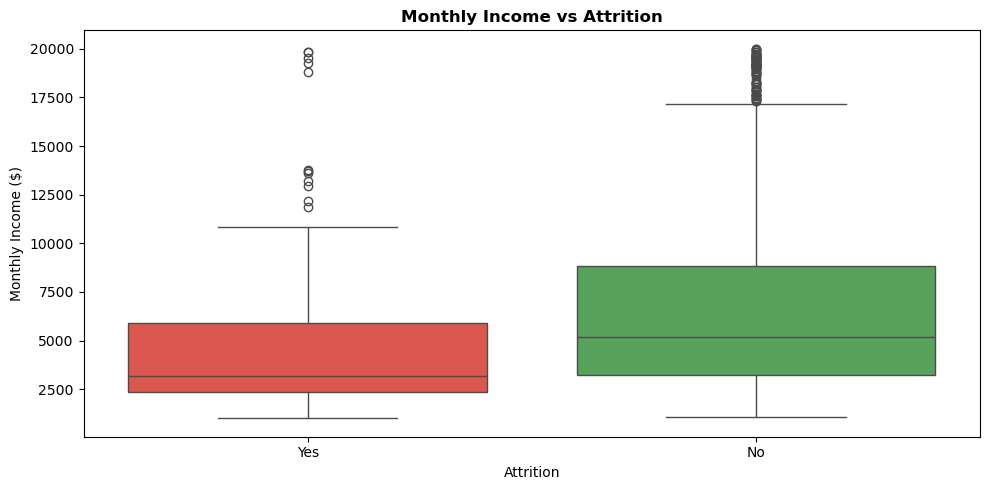

Chart saved!


In [8]:
# We want to check if employees who left
# were earning less than those who stayed

# boxplot shows salary range for each group
# Yes = employees who left
# No  = employees who stayed
plt.figure(figsize=(10, 5))
sns.boxplot(x='Attrition',      # x axis = Yes or No
            y='MonthlyIncome',  # y axis = salary
            data=df,
            palette={'Yes': '#F44336',  # red for left
                     'No': '#4CAF50'})  # green for stayed

plt.title('Monthly Income vs Attrition', fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income ($)')
plt.tight_layout()
plt.savefig('../outputs/02_salary_vs_attrition.png')
plt.show()
print("Chart saved!")

## Key Business Insights

In [9]:
print("=" * 50)
print("KEY BUSINESS INSIGHTS")
print("=" * 50)

# Overall attrition rate
total     = len(df)
left      = df[df['Attrition'] == 'Yes'].shape[0]
attr_rate = round(left / total * 100, 2)

# Which department has highest attrition
# count Yes in each dept / total in dept * 100
top_dept = df[df['Attrition'] == 'Yes']\
             .groupby('Department')['Attrition']\
             .count().idxmax()

# Which job role has highest attrition
top_role = df[df['Attrition'] == 'Yes']\
             .groupby('JobRole')['Attrition']\
             .count().idxmax()

# Attrition rate for overtime employees
overtime_yes = round(
    df[df['OverTime'] == 'Yes']['Attrition']
    .apply(lambda x: 1 if x == 'Yes' else 0)
    .mean() * 100, 2)

# Attrition rate for non overtime employees
overtime_no = round(
    df[df['OverTime'] == 'No']['Attrition']
    .apply(lambda x: 1 if x == 'Yes' else 0)
    .mean() * 100, 2)

# Average salary of employees who left
avg_sal_left = round(
    df[df['Attrition'] == 'Yes']['MonthlyIncome'].mean(), 2)

# Average salary of employees who stayed
avg_sal_stay = round(
    df[df['Attrition'] == 'No']['MonthlyIncome'].mean(), 2)

# Which tenure band has highest attrition
top_tenure = df[df['Attrition'] == 'Yes']\
               .groupby('Tenure Band')['Attrition']\
               .count().idxmax()

# Print all insights
print(f"\n1. Overall Attrition Rate     : {attr_rate}%")
print(f"2. Highest Attrition Dept     : {top_dept}")
print(f"3. Highest Attrition Job Role : {top_role}")
print(f"4. Overtime Attrition Rate    : {overtime_yes}%")
print(f"5. Non-Overtime Attrition Rate: {overtime_no}%")
print(f"6. Avg Salary Who Left        : ${avg_sal_left}")
print(f"7. Avg Salary Who Stayed      : ${avg_sal_stay}")
print(f"8. Highest Attrition Tenure   : {top_tenure}")

KEY BUSINESS INSIGHTS

1. Overall Attrition Rate     : 16.12%
2. Highest Attrition Dept     : Research & Development
3. Highest Attrition Job Role : Laboratory Technician
4. Overtime Attrition Rate    : 30.53%
5. Non-Overtime Attrition Rate: 10.44%
6. Avg Salary Who Left        : $4787.09
7. Avg Salary Who Stayed      : $6832.74
8. Highest Attrition Tenure   : 0-1 yr
